# Captures pour le rapport & la soutenance

**Pipeline de données — Région Nouvelle-Aquitaine**

Chaque cellule = une capture d'écran à mettre dans le rapport / la slide.
Lance **« Run All »**, puis capture chaque cellule (code + résultat).

_Version CSV : aucune dépendance Parquet/pyarrow nécessaire._

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = "c:/Users/ian chel/Desktop/MSPR - big data/economic-pulse-analyzer"
BRUT_ELEC     = f"{ROOT}/MSPR_Final/MSPR/01_Donnees/brut/nouvelle_aquitaine_2012_2017_tour1.csv"
FUSION_SAMPLE = f"{ROOT}/MSPR_Final/MSPR/02_Data_Engineering/notebooks/data_captures/echantillon_fusion.csv"
FINALE_SAMPLE = f"{ROOT}/MSPR_Final/MSPR/02_Data_Engineering/notebooks/data_captures/echantillon_base_finale.csv"
pd.set_option("display.max_columns", 12)
print("Librairies et chemins chargés.")

Librairies et chemins chargés.


## 1. Données électorales brutes (avant nettoyage)
Résultats des présidentielles par canton, **avant tout traitement** : participation (Inscrits / Votants / Exprimés) et **voix réelles par candidat** (nombres entiers de bulletins, non normalisés).

> Le fichier couvre **2012 et 2017** ; on illustre ici le **1er tour 2017** (Macron / Le Pen / Fillon — Macron n'étant pas candidat en 2012).

In [22]:
elec = pd.read_csv(BRUT_ELEC)
print(f"Données brutes : {elec.shape[0]} lignes x {elec.shape[1]} colonnes (avant tout traitement)")
print("Les voix sont des nombres réels de bulletins (entiers), non normalisés.\n")

# Les colonnes candidats sont en ordre de panneau (variable selon l'année).
# On extrait les voix d'un candidat où qu'il soit dans les colonnes Nom.* / Voix.*
nom_cols = [c for c in elec.columns if c == "Nom" or c.startswith("Nom.")]
def voix_candidat(row, cand):
    for nc in nom_cols:
        if row[nc] == cand:
            return row["Voix" if nc == "Nom" else "Voix" + nc[3:]]
    return None

# Scrutin 2017 (Macron / Le Pen / Fillon présents — Macron n'existe pas en 2012)
e17 = elec[elec["Année"] == 2017].copy()
for cand in ["MACRON", "LE PEN", "FILLON"]:
    e17[f"Voix {cand}"] = e17.apply(lambda r: voix_candidat(r, cand), axis=1)
e17 = e17.rename(columns={"Libellé du département": "Département",
                          "Libellé du canton": "Canton"})
e17["Département"] = e17["Département"].str.title()
cols = ["Département", "Canton", "Inscrits", "Votants", "Exprimés",
        "Voix MACRON", "Voix LE PEN", "Voix FILLON"]
e17[cols].head(10)

Données brutes : 756 lignes x 102 colonnes (avant tout traitement)
Les voix sont des nombres réels de bulletins (entiers), non normalisés.



,Département,Canton,Inscrits,Votants,Exprimés,Voix MACRON,Voix LE PEN,Voix FILLON
498,Charente,Angoulême-1,12295,8846,8633,2297,1291,1641
499,Charente,Angoulême-2,12737,9225,8996,2380,1438,1467
500,Charente,Angoulême-3,14409,10513,10294,2891,1514,1858
501,Charente,Boëme-Echelle,14236,11794,11470,2843,2736,1701
502,Charente,Boixe-et-Manslois,13256,10845,10499,2230,2827,1637
503,Charente,Charente-Bonnieure,12930,10139,9806,2208,2172,1448
504,Charente,Charente-Champagne,13209,10547,10252,2319,2481,2188
505,Charente,Charente-Nord,14240,11207,10820,2570,2408,1997
506,Charente,Charente-Sud,14908,11929,11561,2724,2695,2197
507,Charente,Charente-Vienne,13967,11262,10827,2548,2291,1604


## 2. Fusion élections + indicateurs (après fusion)
Jointure des résultats électoraux et des indicateurs socio-économiques sur la clé géographique.
**Base fusionnée : 25 574 lignes × 172 colonnes** (avant augmentation temporelle ; aperçu ci-dessous).

```python
# Code d'origine (notebook de préparation) :
data_fusionnee = pd.merge(elec_df, df_indicateurs, on='CODGEO', how='inner')
```

In [12]:
fusion = pd.read_csv(FUSION_SAMPLE, encoding="utf-8-sig")
print("Colonnes électorales + indicateurs réunies dans une même base :")
fusion[["Libellé du département", "Libellé du canton", "Nom",
        "delta_P22_POP", "delta_P22_EMPLT", "delta_P22_POP1564"]].head(10)

Colonnes électorales + indicateurs réunies dans une même base :


,Libellé du département,Libellé du canton,Nom,delta_P22_POP,delta_P22_EMPLT,delta_P22_POP1564
0,CHARENTE,AIGRE,JOLY,0.010047,0.009959,0.009808
1,CHARENTE,ANGOULÊME-EST,JOLY,0.010289,0.010009,0.010074
2,CHARENTE,ANGOULÊME-NORD,JOLY,0.009599,0.009783,0.010054
3,CHARENTE,BAIGNES-SAINTE-RADEGONDE,JOLY,0.009988,0.010062,0.009836
4,CHARENTE,BLANZAC-PORCHERESSE,JOLY,0.010277,0.010068,0.009925
5,CHARENTE,BROSSAC,JOLY,0.009854,0.010234,0.009578
6,CHARENTE,CHABANAIS,JOLY,0.009687,0.010117,0.009971
7,CHARENTE,CHAMPAGNE-MOUTON,JOLY,0.010317,0.009799,0.009880
8,CHARENTE,CHATEAUNEUF-SUR-CHARENTE,JOLY,0.010219,0.010118,0.010023
9,CHARENTE,COGNAC-NORD,JOLY,0.009840,0.010288,0.010054


## 3. Attributs socio-économiques utilisés
Les **28 variables `delta_`** (variation des indicateurs entre deux périodes) qui alimentent les modèles, **dont `delta_Delinquance`** — la variable la plus déterminante (importance 17,46 %).

In [13]:
finale = pd.read_csv(FINALE_SAMPLE, encoding="utf-8-sig")
feature_cols = [c for c in finale.columns
                if c.startswith("delta_") and "pct" not in c and "eco" not in c]
# Mettre la délinquance en tête (variable la plus déterminante)
if "delta_Delinquance" in feature_cols:
    feature_cols = ["delta_Delinquance"] + [c for c in feature_cols if c != "delta_Delinquance"]
print(f"{len(feature_cols)} attributs delta_ utilisés (dont la délinquance) :\n")
for i, c in enumerate(feature_cols, 1):
    flag = "   <-- variable la plus déterminante du modèle (17,46%)" if c == "delta_Delinquance" else ""
    print(f"{i:2d}. {c}{flag}")

28 attributs delta_ utilisés (dont la délinquance) :

 1. delta_Delinquance   <-- variable la plus déterminante du modèle (17,46%)
 2. delta_P22_POP
 3. delta_P16_POP
 4. delta_SUPERF
 5. delta_NAIS1621
 6. delta_DECE1621
 7. delta_P22_MEN
 8. delta_NAISD24
 9. delta_DECESD24
10. delta_P22_LOG
11. delta_P22_RP
12. delta_P22_RSECOCC
13. delta_P22_LOGVAC
14. delta_P22_RP_PROP
15. delta_P22_EMPLT
16. delta_P22_EMPLT_SAL
17. delta_P16_EMPLT
18. delta_P22_POP1564
19. delta_P22_CHOM1564
20. delta_P22_ACT1564
21. delta_ETTOT23
22. delta_ETAZ23
23. delta_ETBE23
24. delta_ETFZ23
25. delta_ETGU23
26. delta_ETOQ23
27. delta_ETTEF123
28. delta_ETTEFP1023


## 4. Calcul des deltas (différence entre facteurs de même type)
Chaque indicateur est transformé en **variation relative** entre deux périodes.

```python
# Code d'origine (notebook de préparation) :
merged[f'delta_{col}'] = (merged[col_recent] - merged[col_old]) / (merged[col_old] + 1e-9)
```

In [14]:
finale = pd.read_csv(FINALE_SAMPLE, encoding="utf-8-sig")
# On affiche la délinquance + 5 autres variables delta
delta_view = ["delta_Delinquance"] + [c for c in finale.columns
              if c.startswith("delta_") and c != "delta_Delinquance"][:5]
print("Statistiques des variables delta_ (base finale, avec délinquance) :")
finale[delta_view].describe().round(3).T[["mean", "std", "min", "50%", "max"]]

Statistiques des variables delta_ (base finale, avec délinquance) :


,mean,std,min,50%,max
delta_Delinquance,0.381,0.258,0.000,0.297,1.000
delta_P22_POP,0.529,0.171,0.086,0.517,0.965
delta_P16_POP,0.514,0.134,0.012,0.498,0.886
delta_SUPERF,0.464,0.183,0.029,0.471,0.952
delta_NAIS1621,0.457,0.187,0.049,0.448,0.984
delta_DECE1621,0.485,0.158,0.121,0.485,0.955


## 5. Nettoyage — qualité des données
Vérification de l'absence de valeurs manquantes sur les variables du modèle.

In [15]:
manquantes = finale.isnull().sum()
deltas = [c for c in finale.columns
          if c.startswith("delta_") and "pct" not in c and "eco" not in c]
print(f"Colonnes totales        : {finale.shape[1]}")
print(f"Variables delta_ (ML)   : {len(deltas)}  (dont delta_Delinquance)")
print(f"Valeurs manquantes      : {int(manquantes.sum())}")
manquantes[manquantes > 0] if manquantes.sum() else "Aucune valeur manquante — base prête pour le Machine Learning."

Colonnes totales        : 172
Variables delta_ (ML)   : 28  (dont delta_Delinquance)
Valeurs manquantes      : 0


'Aucune valeur manquante — base prête pour le Machine Learning.'

## 5bis. Aperçu lisible de la base finale (dataset d'entraînement)

Sélection des colonnes clés parmi les 172. **À ne pas confondre :**

- **Variables d'entrée du modèle (X)** : `Délinquance`, `Chômage`, `Population` (+ 25 autres `delta_`) — c'est **uniquement** ça que le modèle reçoit.
- **Résultat réel (`Vainqueur réel`, `Orientation réelle`)** : ce sont les **vrais résultats électoraux**, utilisés **seulement pour valider** les prédictions (réel vs prédit). Ils ne sont **jamais** donnés en entrée au modèle → **aucune fuite de données**.

> _L'année et le nombre de voix sont normalisés (MinMax 0–1) pour le modèle, donc volontairement non affichés sous leur forme brute._

In [23]:
# Aperçu lisible : variables d'ENTRÉE (features) vs RÉSULTAT RÉEL (validation)
# On affiche les lignes du scrutin récent (Macron / Fillon / Le Pen) pour rester
# cohérent avec les élections de référence du projet.
ORI = {"exG": "Extrême gauche", "G": "Gauche", "Centre": "Centre",
       "D": "Droite", "exD": "Extrême droite"}
scrutin_recent = ["MACRON", "FILLON", "LE PEN"]
vue = finale[finale["vainqueur_nom"].isin(scrutin_recent)].copy()
apercu = vue.rename(columns={
    "Libellé du département": "Département",
    "Libellé du canton": "Canton",
    "delta_Delinquance": "Délinquance",
    "delta_P22_CHOM1564": "Chômage",
    "delta_P16_POP": "Population",
    "vainqueur_nom": "Vainqueur réel",
    "orientation": "Orientation réelle",
})
apercu["Orientation réelle"] = apercu["Orientation réelle"].map(ORI).fillna(apercu["Orientation réelle"])
apercu["Département"] = apercu["Département"].str.title()
apercu = apercu.drop_duplicates(subset=["Département", "Canton"])

# Variables d'ENTRÉE du modèle (extrait des 28 delta_) — PUIS le résultat réel (validation)
features_X   = ["Délinquance", "Chômage", "Population"]
validation_y = ["Vainqueur réel", "Orientation réelle"]
print("ENTRÉE du modèle (X) :", features_X, "(+ 25 autres delta_)")
print("RÉSULTAT réel (validation, JAMAIS en entrée) :", validation_y)
cols = ["Département", "Canton"] + features_X + validation_y
apercu[cols].round(3).head(10)

ENTRÉE du modèle (X) : ['Délinquance', 'Chômage', 'Population'] (+ 25 autres delta_)
RÉSULTAT réel (validation, JAMAIS en entrée) : ['Vainqueur réel', 'Orientation réelle']


,Département,Canton,Délinquance,Chômage,Population,Vainqueur réel,Orientation réelle
1,Landes,Adour Armagnac,0.355,0.298,0.235,MACRON,Centre
3,Dordogne,Sud-Bergeracois,0.130,0.690,0.594,LE PEN,Extrême droite
5,Haute-Vienne,Limoges-5,0.293,0.551,0.600,MACRON,Centre
8,Charente,Cognac-2,0.445,0.481,0.692,MACRON,Centre
9,Charente,Jarnac,0.445,0.360,0.435,MACRON,Centre
10,Corrèze,Ussel,0.156,0.724,0.417,MACRON,Centre
12,Dordogne,Vallée Dordogne,0.130,0.526,0.348,MACRON,Centre
18,Dordogne,Ribérac,0.130,0.582,0.469,LE PEN,Extrême droite
22,Gironde,Le Bouscat,1.000,0.482,0.569,MACRON,Centre
26,Charente,Boixe-et-Manslois,0.445,0.528,0.545,LE PEN,Extrême droite


## 6. Base de données finale + corrélations
Aperçu de la base finale et matrice de corrélation entre indicateurs socio-économiques.

,delta_Delinquance,delta_P22_POP,delta_P16_POP,delta_P22_LOG,delta_P22_LOGVAC,delta_P22_EMPLT,delta_P22_EMPLT_SAL,delta_P16_EMPLT,delta_P22_POP1564
0,0.1301,0.297396,0.501173,0.619157,0.587248,0.156912,0.210182,0.285405,0.622245
1,0.3547,0.269476,0.235143,0.574415,0.662727,0.540000,0.236368,0.273801,0.355888
2,0.1301,0.643319,0.613961,0.100091,0.270006,0.665205,0.351670,0.424537,0.462845
3,0.1301,0.268490,0.593532,0.541805,0.480703,0.419814,0.763803,0.216954,0.093431
4,0.2972,0.681955,0.552828,0.454474,0.373704,0.510909,0.518764,0.310843,0.436587


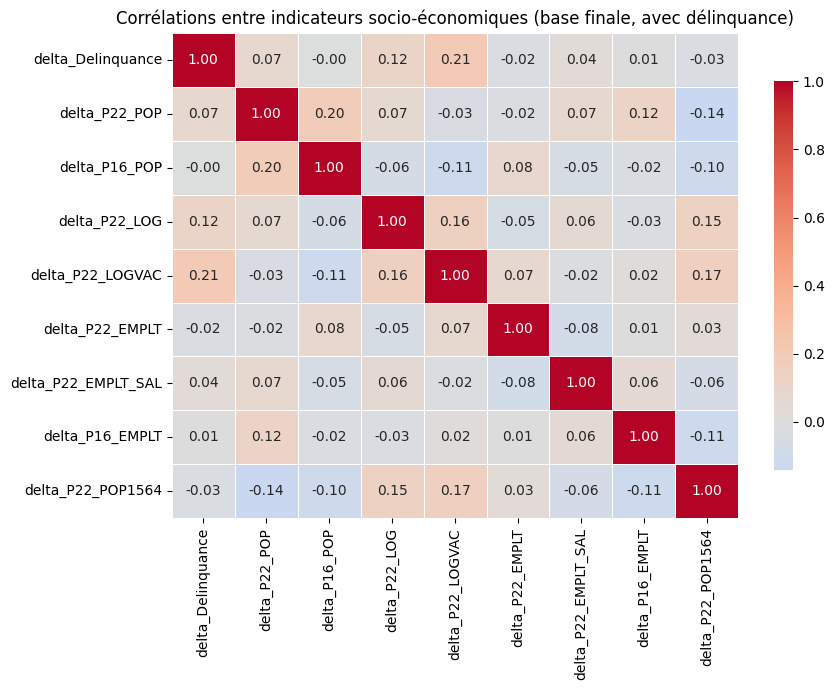

In [17]:
eco = ["delta_Delinquance"] + [c for c in finale.columns
       if c.startswith("delta_") and any(x in c.lower() for x in ["pop", "emplt", "act", "log", "chom"])][:8]
display(finale[eco].head(5))

corr = finale[eco].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Corrélations entre indicateurs socio-économiques (base finale, avec délinquance)")
plt.tight_layout()
plt.show()